In [1]:
import glob
import pandas as pd
import re
import unicodedata

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kanchana1990/global-food-nutrition-database10k-products")

print("Path to dataset files:", path)

/opt/homebrew/Caskroom/miniforge/base/envs/bootcamp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/mikel/.cache/kagglehub/datasets/kanchana1990/global-food-nutrition-database10k-products/versions/1


In [3]:
# con la libreria glob, poniendo un "*" al final, vemos la ruta completa del csv para importarla con pandas

glob.glob("/home/mikel/.cache/kagglehub/datasets/kanchana1990/global-food-nutrition-database10k-products/versions/1/*")

[]

In [4]:
food = pd.read_csv('/home/mikel/.cache/kagglehub/datasets/kanchana1990/global-food-nutrition-database10k-products/versions/1/openfoodfacts_nutrition_final_2025-12-10.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/home/mikel/.cache/kagglehub/datasets/kanchana1990/global-food-nutrition-database10k-products/versions/1/openfoodfacts_nutrition_final_2025-12-10.csv'

In [ ]:
food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9804 entries, 0 to 9803
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                9804 non-null   int64  
 1   product_name        9566 non-null   object 
 2   brands              9430 non-null   object 
 3   countries           9802 non-null   object 
 4   quantity            8816 non-null   object 
 5   categories          9683 non-null   object 
 6   labels              7552 non-null   object 
 7   nutriscore_grade    9801 non-null   object 
 8   ecoscore_grade      9802 non-null   object 
 9   nova_group          8959 non-null   float64
 10  ingredients_text    9406 non-null   object 
 11  energy-kcal_100g    9280 non-null   float64
 12  fat_100g            9309 non-null   float64
 13  saturated-fat_100g  9140 non-null   float64
 14  carbohydrates_100g  9284 non-null   float64
 15  sugars_100g         9168 non-null   float64
 16  fiber_

## Unificación de países y selección del país principal 

In [ ]:
food["countries"].unique().tolist()

['Morocco',
 'Morocco,United States',
 'المغرب',
 "Belgium,Côte d'Ivoire,France,Germany,Guadeloupe,Italy,Luxembourg,Mali,Martinique,New Caledonia,Switzerland,United Kingdom",
 'Democratic Republic of the Congo,Mauritania,Morocco,United States',
 'Maroc,en:morocco',
 'Maroc',
 'France,Germany,Ireland,Italy,Netherlands,Spain,United Kingdom,United States',
 'Algeria,Belgium,France,French Polynesia,Germany,Guadeloupe,Hungary,Luxembourg,Martinique,Morocco,New Caledonia,Réunion,Spain,Switzerland,United States',
 'Algérie,Autriche,Belgique,Bulgarie,Canada,République tchèque,Finlande,France,Polynésie française,Allemagne,Irlande,Italie,Maurice,Maroc,Pays-Bas,Norvège,La Réunion,Roumanie,Singapour,Espagne,Suède,Suisse,Tunisie,Royaume-Uni',
 'Algérie,Belgique,Bulgarie,France,Allemagne,Guadeloupe,Inde,Italie,Luxembourg,Martinique,Maroc,La Réunion,Espagne,Suisse,Tunisie,Royaume-Uni,États-Unis',
 'Marocco',
 'Maroc,États-Unis',
 'Belgium, Bulgaria, France, en:switzerland',
 'Ireland,United Kingdom,Un

In [ ]:
import pandas as pd
import re

def filtrar_potencias(df, columna='countries'):
    # 1. Definimos los patrones de búsqueda (Regex)
    patrones = {
        'Spain': r'Spain|España|Espagne|Espanha|ES|en:es',
        'France': r'France|Francia|França|FR|en:fr',
        'Germany': r'Germany|Alemania|Allemagne|Deutschland|DE|en:de',
        'United Kingdom': r'United Kingdom|UK|Reino Unido|Royaume-Uni|GB|en:gb|Great Britain',
        'Maghreb': r'Morocco|Maroc|Marruecos|Algeria|Algérie|Tunisia|Tunisie|MA|DZ|TN|en:ma|المغرب',
        'Italy': r'Italy|Italia|Italie|IT|en:it',
        'Benelux': r'Belgium|Belgique|België|Netherlands|Nederland|Pays-Bas|BE|NL',
        'Alpine (CH/AT)': r'Switzerland|Suisse|Schweiz|Austria|Österreich|CH|AT',
        'Nordics': r'Norway|Sweden|Sverige|Denmark|Danmark|Finland|Suomi|NO|SE|DK|FI',
        'Eastern Europe': r'Poland|Polska|Romania|România|Bulgaria|Czech|Hungary|PL|RO',
        'Americas': r'United States|USA|EEUU|Argentina|Mexico|México|Canada|US|MX|AR|CA',
        'Ireland': r'Ireland|Irlanda|en:ie|IE',
        'Portugal': r'Portugal|Portugália|en:pt|PT'
    }

    patron_global = '|'.join(patrones.values())
    
    # Filtramos el DataFrame original
    df_result = df[df[columna].str.contains(patron_global, case=False, na=False)].copy()

    # 2. Lógica de etiquetado priorizada
    def etiquetar_pais(row):
        val = str(row).lower()
        if any(term in val for term in ['spain', 'españa', 'espagne', 'es:']): return 'Spain'
        if any(term in val for term in ['france', 'frança', 'fr:']): return 'France'
        if any(term in val for term in ['germany', 'alemania', 'deutschland', 'de:']): return 'Germany'
        if any(term in val for term in ['united kingdom', 'uk', 'gb:', 'en:gb']): return 'United Kingdom'
        if any(term in val for term in ['morocco', 'maroc', 'marruecos', 'algeria', 'tunisia', 'ma:', 'المغرب']): return 'Maghreb'
        if any(term in val for term in ['switzerland', 'suisse', 'schweiz', 'austria', 'österreich', 'ch:', 'at:']): return 'Alpine (CH/AT)'
        if any(term in val for term in ['sweden', 'denmark', 'finland', 'norway', 'norge']): return 'Nordics'
        if any(term in val for term in ['belgium', 'belgique', 'netherlands', 'holland']): return 'Benelux'
        if any(term in val for term in ['poland', 'romania', 'bulgaria', 'hungary', 'czech']): return 'Eastern Europe'
        if any(term in val for term in ['ireland', 'ie:']): return 'Ireland'
        if any(term in val for term in ['italy', 'italia', 'it:']): return 'Italy'
        if any(term in val for term in ['usa', 'united states', 'mexico', 'argentina', 'canada']): return 'Americas'
        if any(term in val for term in ['portugal', 'pt:']): return 'Portugal'
        return 'Other / Global'

    df_result['main_country'] = df_result[columna].apply(etiquetar_pais)
    
    # 3. Métricas de Cobertura
    total_original = len(df)
    total_clasificado = len(df_result)
    porcentaje_cobertura = (total_clasificado / total_original) * 100
    
    counts = df_result['main_country'].value_counts()
    percentages = (counts / total_clasificado) * 100
    
    tabla_final = pd.DataFrame({
        'Número de Productos': counts,
        'Porcentaje (%)': percentages.round(2)
    })
    
    print("\n" + "="*50)
    print("      INFORME DE DISTRIBUCIÓN GEOGRÁFICA")
    print("="*50)
    print(tabla_final)
    print("-" * 50)
    print(f"RESUMEN: Se ha clasificado el {porcentaje_cobertura:.2f}% del dataset original ({total_clasificado} de {total_original} productos).")
    print("="*50)
    
    return df_result

# Ejecución
food_countries = filtrar_potencias(food)


      INFORME DE DISTRIBUCIÓN GEOGRÁFICA
                Número de Productos  Porcentaje (%)
main_country                                       
France                         4836           49.66
United Kingdom                 1471           15.11
Spain                          1119           11.49
Other / Global                  836            8.58
Maghreb                         685            7.03
Germany                         448            4.60
Americas                         80            0.82
Portugal                         63            0.65
Eastern Europe                   52            0.53
Italy                            51            0.52
Ireland                          35            0.36
Alpine (CH/AT)                   30            0.31
Benelux                          20            0.21
Nordics                          12            0.12
--------------------------------------------------
RESUMEN: Se ha clasificado el 99.33% del dataset original (9738 de 9804 pro

## Clasificación de productos por categoría

In [ ]:
def unificacion_categorias(df, columna='categories'):
    def limpiar(txt):
        if pd.isna(txt): return "Otros"
        txt = re.sub(r'[a-z]{2}:', '', str(txt)).lower()
        
        # 1. BEBIDAS VEGETALES Y SUSTITUTOS (Prioridad Máxima)
        if any(p in txt for p in ['vegetarian nuggets', 'fleisch-ersatzprodukte', 'soy-based-drinks', 'vegetarian patties', 'vegetarian sausages', 'soy-based', 'crèmes végétales', 'vege mince', 'mince', 'soy-based drinks', 'galettes de soja', 'vegan', 'oat based drinks', 'galettes de soja', 'soja', 'vegetable-based', 'galettes végétariennes', 'produits sans gluten', 'plantaardige', 'haverdranken', 'melkvervangers', 'galettes végétariennes', 'milk substitute', 'substitut de lait', 'substitute', 'alternative', 'vegetal milk', 'leche vegetal', 'lait végétal', 'tofu', 'seitan', 'heura', 'vegan meat']):
            return 'plant_based_alternatives'

        # 2. NUTRICIÓN INFANTIL (Tienen un Nutri-Score muy específico)
        if any(p in txt for p in ['cerelac', 'baby', 'bébé', 'infantil', 'bebé', 'potitos', 'babyfood', 'toddler', 'children pate']):
            return 'baby_food'

        # 3. PLATOS PREPARADOS Y CONVENIENCIA
        if any(p in txt for p in ['surgelés', 'pommes noisettes', 'cod acras', 'feuilles de brick', 'caldos', 'caldos líquidos', 'brou', 'spinach bites', 'vegetable rice', 'vegetable patties', 'tortilla', 'comidas-preparadas', 'courgettes cuisinées', 'prepared vegetables', 'puré', 'black dhal', 'kimchi', 'dumplings', 'purées', 'puree', 'luncheon', 'اللحوم المصنعة', 'refeições', 'refeições para micro-ondas', 'processed vegetables', 'prepared vegetables', 'maaltijden', 'ready-made', 'comidas-preparadas', 'tortilla', 'tortillas-de-patata', 'taboule', 'maaltijden', 'instant-noodles', 'tabouleh', 'taboulehs', 'kant-en-klaar maaltijden', 'maaltijden', 'hash browns', 'fries', 'chips and fries', 'gravy', 'stuffing', 'soups', 'bouillon', 'broths', 'meals', 'ready-to-eat', 'soups', 'bouillon', 'broths', 'stuffing', 'fries', 'potatoes', 'meals', 'ready', 'préparé', 'preparado', 'pizza', 'lasagna', 'sandwich', 'hummus', 'sushi', 'take away']):
            return 'ready_to_eat'

        # 4. LÁCTEOS Y HUEVOS (Animal)
        if any(p in txt for p in ['mosarella', 'ferments-lactiques', 'zuivelproducten', 'mliječni proizvodi', 'slastice', 'raïb', 'tejtermékek', 'krémek', 'كعكة', 'crèmes fraîches', 'creme', 'masła', 'nabiał', 'tłuszcze mleczne', 'slastice', 'pjenice', 'mliječni', 'yaourt', 'ياغورت', 'laticínios', 'natilhas', 'chees', 'zuivelproducten', 'cream', 'kefir', 'skir', 'млечни', 'latte', 'milchprodukte', 'creams', 'oeufs', 'œufs', 'oeufs', 'œufs', 'creams', 'dairy', 'laitier', 'lácteo', 'cheese', 'fromage', 'queso', 'yogurt', 'yaourt', 'milk', 'lait', 'leche', 'egg', 'oeuf', 'huevo']):
            if 'vegan' in txt or 'plant-based' in txt: return 'plant_based_alternatives'
            return 'dairy_eggs'

        # 5. CARNE Y PESCADO (Animal)
        if any(p in txt for p in ['tonijn', 'conserven', 'tonijn op olie', 'turkey bacon', 'tuna-in-catalan', 'tuna', 'bacon', 'canned-tunas', 'mackerel-fillets', 'tunas', 'mackerel', 'chipolatas', 'charcuterie', 'charcuteries', 'charcuterie de volaille', 'vissen', 'makreel', 'pechuga de pavo', 'meat', 'viande', 'carne', 'fish', 'poisson', 'pescado', 'atún', 'thon', 'sardine', 'chicken', 'poulet', 'pollo', 'ham', 'jambon', 'jamón']):
            if 'vegan' in txt or 'plant-based' in txt: return 'plant_based_alternatives'
            return 'meat_fish'

        # 6. DULCES, SNACKS Y POSTRES
        if any(p in txt for p in ['kakao', 'kakaov', 'zrna kakaa', 'pommes noisettes', 'gum', 'pastry', 'croissants', 'waffles', 'caramel', 'matzos', 'cracker', 'waffles', 'caramel', 'chocholat', 'malt loaf', 'cakes', 'закуски', 'сладки закуски', 'przekąski', 'słodkie przekąski', 'batoniki', 'cake', 'cocoa cake','cakes', 'pufuleți', 'biscuit', 'بسكويت', 'barre céréalière', 'confiture', 'confitures', 'biscuit', 'bonbons', 'aliments de pâques', 'lentil & pea cakes', 'appetizers', 'grickalice', 'slatki zalogaji', 'biscoitos', 'bolos', 'bonbons', 'biscuit', 'lanches doces', 'gelatina', 'biscotti', 'wafers', 'chewing-gum', 'flan', 'crisps', 'crackers', 'confectioneries', 'bars', 'chips', 'crackers', 'wafers', 'confectioneries', 'flans', 'bars', 'chips', 'crisps', 'snack', 'biscuits', 'gateaux', 'galletas', 'chocolat', 'candy', 'confectionery', 'sweet', 'sucré', 'dessert', 'ice cream', 'glace', 'helado']):
            return 'snacks_sweets'

        # 7. GRASAS, ACEITES Y SALSAS
        if any(p in txt for p in ['dips', 'vetten', 'pate', 'huil', 'sriracha', 'sauces', 'ouile', 'matière grasse', 'matières grasses', 'sojasauzen', 'chutneys', 'aceto balsamico', 'essige', 'smaakmakers', 'sauzen', 'olivenöle', 'butter', 'beurre', 'moutarde', 'mustard', 'senf', 'jams', 'confitures', 'beurres de cacahuètes', 'syrups', 'sirops', 'agave', 'confitures', 'butter', 'erdnussbutter', 'oil', 'huile', 'aceite', 'sauce', 'condiment', 'ketchup', 'pesto', 'spread', 'tartiner', 'untable', 'mayo', 'margarine', 'vinegar', 'vinaigre', 'vinagre']):
            return 'fats_sauces'

        # 8. CEREALES, PAN Y PASTAS
        if any(p in txt for p in ['wheats', 'rolled oats', 'ciabatta', 'oats', 'nourriture', 'malt loaf', 'spaghetti', 'extruded flakes', 'flakes', 'céréalière', 'germes de blé', 'granola', 'porridge', 'sourdough', 'brioches', 'germé de blé', 'pahuljice', 'crêpes', 'galettes de froment', 'tartines craquantes', 'pahuljice', 'zobene pahuljice', 'germe de blé', 'knäckebrote', 'biscottes', 'semoule', 'rusks', 'müsli', 'getreide', 'crumpets', 'rices', 'frühstückscerealien', 'flour', 'farine', 'knäckebrote', 'crumpets', 'rices', 'müslis', 'getreide', 'frühstückscerealien', 'céréale', 'cereals', 'bread', 'pain', 'pan', 'pão', 'pasta', 'pâte', 'muesli', 'breakfast', 'flour', 'farine', 'harina']):
            return 'cereals_bread'

        # 9. BEBIDAS (Aguas, Refrescos, Café, Té)
        txt_sin_ruido = txt.replace('plant-based foods and beverages', '')
        if any(p in txt_sin_ruido for p in ['entergy', 'dranken en drankbereidingen', 'frisdranken', 'tonics', 'gesuikerde dranken', 'напитки', 'вода', 'limonaden', 'gezuckerte getränke', 'juomat', 'tisanes', 'infusions', 'apa', 'napoje', 'woda', 'gazirana', 'sportdrank', 'chicorée soluble', 'chicorée', 'sprite', 'مشروب', 'getränkezubereitungen', 'energy-drinks', 'pića', 'pripravci za piće', 'soft drinks', 'kola kola', 'gazirana pića', 'boissons', 'beverage', 'boisson', 'bebida', 'bevande', 'water', 'eau', 'agua', 'juice', 'jus', 'zumo', 'soda', 'cola', 'coffee', 'café', 'tea', 'thé', 'té']):
            return 'beverage'

        # 10. ALCOHOL (Importante: Nutri-Score no suele aplicar aquí)
        if any(p in txt for p in ['alcohol', 'vin', 'wine', 'beer', 'bière', 'cerveza', 'spirit', 'liqueur']):
            return 'alcoholic_beverages'

        # 11. SUPLEMENTOS Y NUTRICIÓN DEPORTIVA
        if any(p in txt for p in ['supplement', 'complément', 'suplemento', 'protein powder', 'whey', 'vitamin', 'vitamine', 'nahrungsergänzungsmittel', 'proteinpulver', 'proteinshakes', 'bodybuilder']):
            return 'supplements_nutrition'

        # 12. VEGETALES, FRUTAS Y LEGUMBRES (Frescos/Conservas simples)
        if any(p in txt for p in ['castañas', 'red kidney beans', 'kidney beans', 'frozzen vegetables', 'frozen-vegetables', 'kasvipohjaiset', 'hedelmä', 'seeds', 'canned lentils', 'lentils', 'courgettes', 'prunes', 'dried-prunes', 'semillas', 'chía', 'maïs frit', 'corn', 'walnüsse', 'seeds', 'cauliflower rice', 'frozen-vegetables', 'nut', 'noix', 'vegetal', 'plant-based', 'fruit', 'fruta', 'légume', 'verdura', 'tomato', 'tomate', 'nut', 'noix', 'frutos secos', 'legume', 'legumbre']):
            return 'plant_based'
            
        # 13. ESPECIAS Y POLVOS PARA COCINAR
        if any(p in txt for p in ['vanilla', 'extract', 'cane-sugar', 'sucre-de-canne', 'endulzantes', 'ciclamato', 'sugars', 'ingredients', 'المكونات', 'aides culinaires', 'honey', 'miels', 'honige', 'bienenprodukte', 'cannelle', 'aides culinaires', 'edulcoranti', 'sciroppi', 'acero', 'siroppi', 'sucres roux', 'cassonades', 'yeast', 'sucres', 'cassonades', 'agave', 'sirops', 'additifs', 'édulcorants', 'sucralose', 'sweetener', 'spice', 'épice', 'especia', 'baking', 'levure', 'powder', 'sel', 'salt', 'sal']):
            return 'spices_baking_sugars'

        return "Otros"

    df['category_unified'] = df[columna].apply(limpiar)
    
    # Reporte de Cobertura
    total = len(df)
    otros_count = df[df['category_unified'] == 'Otros'].shape[0]
    print(f"Limpieza completa. 'Otros' se ha reducido al {(otros_count/total)*100:.2f}% del dataset.")
    
    return df

food_countries = unificacion_categorias(food_countries)
print(food_countries['category_unified'].value_counts())

Limpieza completa. 'Otros' se ha reducido al 1.43% del dataset.
category_unified
snacks_sweets               2593
ready_to_eat                1896
dairy_eggs                  1674
fats_sauces                  945
beverage                     774
cereals_bread                589
plant_based_alternatives     525
meat_fish                    349
plant_based                  145
Otros                        139
spices_baking_sugars          71
supplements_nutrition         18
baby_food                     15
alcoholic_beverages            5
Name: count, dtype: int64


## Clasificación de productos por marca

In [ ]:
def normalizar(texto):
    if pd.isna(texto): return ""
    # Transforma 'Nestlé' en 'Nestle' y pasa a minúsculas
    texto = unicode_str = unicodedata.normalize('NFD', str(texto))
    return "".join([c for c in unicode_str if unicodedata.category(c) != 'Mn']).lower().strip()

mapping = {
    # ======================
    # GRANDES MULTINACIONALES
    # ======================
    'Nestlé': [
        'nestle', 'nescafe', 'nescafé', 'nesquik', 'maggi', 'chocapic',
        'garden gourmet', 'le chocolat', 'lion', 'kitkat', 'after eight',
        'cookie crisp', 'golden grahams', 'herta', 'la laitiere', 'la laitière',
        'la laitiere, la laitière', 'mousline', 'vittel', 'perrier', 'badoit',
        'solis', 'buino', 'ricore', 'dolce gusto', 'cailler', 'ovomaltine',
        'ovo maltine', 'cappuccino, gold cappuccino, nescafé'
    ],

    'Unilever': [
        'unilever', 'marmite', 'hellmann', "hellman's", 'hellmanns',
        'knorr', 'knoor', 'amora', 'maizena', 'ben & jerry', 'ben & jerry\'s',
        'maille', 'frigo', 'ligeresa', 'calve', 'calvé', 'flora', 'planta fin',
        'flora proactiv', "fruit d'or", "fruit d'or proactiv, pro activ, proactiv, proactiv expert",
        "fruit d'or,becel", "fruit d'or proactiv,proactiv,proactiv expert,pro activ",
        'lipton', 'benedicta', 'bénédicta', 'skip', 'dove',
        'pukka', 'fruittare', 'the vegetarian butcher', 'magnum', 'magnum', 'miko', 'graze'
    ],

    'Mondelez': [
        'mondelez', 'lu', 'lu ', ' lu', 'lu,', 'lu.', 'milka', 'oreo',
        'toblerone', 'tuc', 'belvita', 'cadbury', 'philadelphia',
        'cote d’or', "cote d'or", "côte d'or", 'granola', 'heudebert',
        'pelletier', 'mikado', 'fontaneda', 'principe', 'príncipe', 'barny',
        'oscar mayer', 'belin', 'royal', 'daunat', 'jacob', 'mcvitie', 'nippon'
    ],

    'Danone': [
        'danone', 'activia', 'evian', 'volvic', 'alpro', 'hipro',
        'savane', 'font vella', 'lanjarón', 'les 2 vaches', 'oatly',
        'la salvetat', 'salvetat', 'vrai', 'charles & alice', 'michel & augustin',
        'michel et augustin', 'siggi', 'nyakas', 'danao'
    ],

    'Ferrero': [
        'ferrero', 'nutella', 'kinder', 'rocher', 'tic tac', 'tictac',
        'raffaello', 'mon cheri', 'mon chéri', 'mon chéri', "MON CHÉRI"
    ],

    'PepsiCo': [
        'pepsico', 'pepsi', 'lays', "lay's", 'lay&#039;s', 'doritos', 'cheetos',
        'alvalle', 'quaker', 'gatorade', 'tropicana', 'cruesli', 'matutano',
        'benenuts', 'sun bites', 'sun bites', 'walkers', 'AQUAFINA'
    ],

    'Coca-Cola': [
        'coca-cola', 'coca cola', 'coke', 'fanta', 'sprite', 'fuze tea',
        'aquarius', 'minute maid', 'pulco', 'honest', 'innocent', 'powerade',
        'monster energy', 'nestea', 'adez', 'cappy', 'smartwater',
        'the coca cola company'
    ],

    'Kellogg': [
        'kellogg', "kellog's", 'special k', 'all-bran', 'frosties',
        'smacks', 'tresor', 'cheerios', 'cheerios multigrain', 'pringles', 'Pringles', 'PRINGLES'
    ],

    'General Mills': [
        'general mills', 'nature valley', 'old el paso', 'haagen-dazs',
        'häagen-dazs', 'jus rol', 'pillsbury', 'green giant', 'gigante verde', 'yoplait', 'yop', 'petit filous'
    ],

    'Kraft Heinz': [
        'heinz', 'kraft', 'orlando', 'hp sauce', 'lea & perrins'
    ],

    'Mars Wrigley': [
        'mars', 'm&m', "m&m's", 'snickers', 'twix', 'orbit', 'skittles',
        'maltesers', 'celebrations', 'reese', 'whiskas', 'pedigree',
        'ebly', "ben's original", 'suzi wan'
    ],

    'Dr. Oetker': [
        'dr. oetker', 'dr oetker', 'alsa', 'ancel', 'condi', 'muesli crunchy',
        'muesli crunchy'
    ],

    'Deoleo / Aceites': [
        'deoleo', 'carapelli', 'bertolli', 'carbonell', 'koipe', 'hula'
    ],

    'Valeo Foods': [
        'valeo foods', 'balconi', 'kettle', 'kettle chips', 'rowan hill'
    ],

    'Princes Group': [
        'princes', 'napolina', 'juver'
    ],

    'Ecotone / Wessanen': [
        'ecotone', 'wessanen', 'bjorg', 'alter eco',
        'allos', 'clipper', 'tanoshi', 'zonnatura', 'whole earth', 'isitar'
    ],

    'Upfield': [
        'becel', "fruit d'or", 'proactiv', 'pro activ',
        "fruit d'or proactiv,proactiv,proactiv expert,pro activ",
        "fruit d'or,becel", "fruit d'or proactiv, pro activ, proactiv, proactiv expert",
        "fruit d'or proactiv,proactiv,proactiv expert, pro activ"
    ],

    # ======================
    # MARCAS DE DISTRIBUIDOR / RETAILERS
    # ======================

    'Hacendado / Mercadona': [
        'hacendado', 'mercadona', 'deliplus', 'compy', 'bosque verde',
        'entrepinares', 'facendado', 'FACENDADO'
    ],

    'Lidl': [
        'lidl', 'alesto', 'milbona', 'fin carré', 'fin carre', 'sondey',
        'freshona', 'crownfield', 'vemondo', 'vermondo', 'baresa',
        'j.d. gross', 'bellarom', 'combino', 'italiamo', 'snack day',
        'envia', 'nixe', 'maribel', 'saguaro', 'trattoria', 'gelatelli',
        'toque du chef', 'duc de coeur', 'deluxe', "vitad'or",
        "vita d'or", 'belbake', 'primadonna', 'solesita', 'tastino',
        'harvest basket', 'maître jean pierre', 'maitre jean pierre',
        'mister choc', 'favourina', 'favorina', 'rivercote', 'solevita'
    ],

    'Carrefour / Système U / Intermarché': [
        'carrefour', 'reflets de france', 'eco +', 'eco+',
        'nos regions ont du talent', 'nos régions ont du talent',
        'nos regions ont du talent', 'nos régions ont du talent',
        'u bio', 'magasins u', 'u ', 'u,', 'u', 'paturages', 'pâturages',
        'páturages', 'paturages, sélection des mousquetaires',
        'sélection des mousquetaires', 'les mousquetaires',
        'nos regions ont du talent', 'nos régions ont du talent',
        'itineraires des saveurs', 'itinéraire des saveurs',
        'itinéraire des saveurs, les mousquetaires',
        'itineraires de nos regions',
        'saveurs de nos regions', 'saveurs de nos régions',
        'saveurs de nos régions', 'saveurs de nos regions'
    ],

    'Leclerc': [
        'e.leclerc', 'bio village', 'marque repère', 'marque repere',
        'saveurs de nos régions', 'saveurs de nos regions'
    ],
    
    'Aldi': [
        'aldi', 'harvest morn', 'savour bakes', 'specially selected', 
        'the foodie market', 'village bakery', 'bramwells', 'brooklea', 'four seasons', 'valencia'
    ],

    'Retail Internacional (Otros)': [
        'tesco', 'sainsbury', 'waitrose', 'marks & spencer', 'marks and spencer',
        'm&s', 'auchan', 'migros', 'coop', 'picard', 'costco',
        'asda', 'morrisons', 'système u', 'dia', 'el corte inglés',
        'mcennedy', 'stockwell', 'monoprix', 'woolworths food',
        'co op', 'the co-operative loved by us',
        'kirkland', 'kirkland signature', "member's mark"
    ],
    
    'Intermarche': [
        'intermarche', 'intermarché', 'chabrior', "bouton d'or"
    ],

    # ======================
    # GRANDES GRUPOS LÁCTEOS / QUESOS
    # ======================

    'Lactalis / Bel': [
        'lactalis', 'président', 'president', 'galbani', 'lactel', 'puleva',
        'lauki', 'société', 'société', 'bridelice', 'bridelight',
        'kiri', 'babybel', 'la vache qui rit', 'boursin', 'leerdammer',
        'candia', 'milsa', 'pilos', 'grand fermage', 'le petit basque',
        'la laitìère', 'la laitière', 'la laitiere', 'nurishh'
    ],

    'Savencia': [
        'savencia', 'st moret', 'saint moret', 'tartare', 'caprice des dieux',
        'saint agur', 'elle & vire', 'elle&vire', 'cœur de lion', 'chavroux',
        'bordeau chesnel', 'le rustique', 'fromarsac', 'rians'
    ],

    'FrieslandCampina': [
        'frieslandcampina', 'milko', 'longley farm'  # milko depende de país, se incluye como aproximación
    ],

    'Arla': [
        'arla', 'castello', 'lurpak'  # si lo tienes, añade otras marcas arla
    ],

    # ======================
    # OTROS GRANDES GRUPOS EUROPEOS
    # ======================

    'Barilla / Pasta': [
        'barilla', 'wasa', 'mulino bianco', 'harry', 'harrys',
        'de cecco', 'rummo', 'panzani', 'giovanni rana', 'rana',
        'misura', 'garofalo', 'jacquet', 'gran cereale', 'gran cereale'
    ],

    'Associated British Foods (ABF)': [
        'jordans', 'dorset cereals', 'twinings', 'ryvita', 'patak',
        'primark', 'allinson', 'kingsmill', 'silver spoon'
    ],

    'Ebro Foods / Mutti': [
        'ebro foods', 'brillante', 'sos', 'lustucru', 'taureau ailé',
        'tilda', 'mutti', 'liebig'
    ],
    
    'GB Foods': [
        'star', 'gallina blanca', 'avecrem', 'yatekomo'

    ],

    'Grandes Grupos Europeos': [
        'fleury michon', 'fleurs michon', 'bonne maman', 'andros',
        'gerblé', 'gerble', 'bonduelle', 'brioche pasquier', 'pasquier',
        'st michel', 'saint michel', 'la boulangère', 'la boulangere',
        'sodebo', 'tipiak', 'gullon', 'gullón', 'cuetara', 'cuétara',
        'mccain', 'mc cain', 'findus', 'bimbo', 'haribo', 'ricola',
        'st hubert', 'paysan breton', 'lotus', 'weetabix', 'pascual',
        'don simón', 'don simon', 'elpozo', 'campofrío', 'campofrio',
        'marie', 'petit navire', 'saupiquet', 'connetable', 'connétable',
        'poulain', 'lucien georgelin', 'pierre martinet', "d'aucy",
        'soignon', 'lesieur', 'quorn', 'entremont', 'william saurin',
        'jaouda', 'chergui', 'aicha', 'cassegrain', 'brets', "bret's",
        'warburtons', 'vico', 'seeberger', 'puget', 'primevère',
        'brossard', 'le gaulois', 'lutti', 'lune de miel', 'francine',
        'le ster', 'coraya', 'storck', 'hovis', 'tramier', 'yeo valley',
        'filippo berio', 'kikkoman', 'saclà', 'lindt', 'sprüngli',
        'bahlsen', 'bahlsen,leibniz', 'leibniz', 'Lotus Bakeries', 
        'lotus', 'nakd', 'bear', 'biscoff'

    ],

    # ======================
    # BIO / SALUD (GRUPOS GRANDES)
    # ======================

    'Léa Nature / Bio Salud': [
        'jardin bio', 'jardin bio étic', 'lea nature', 'léa nature',
        'karelea', 'bisson', 'evernat', 'ethiquable', 'éthiquable',
        'cereal bio', 'céréal bio', 'sojasun', 'taifun', 'soy',
        'happyvore', 'ecomil', 'eco mil', 'alnatura', 'huel',
        'deliciously ella', 'violife', 'pure via', 'dmbio', 'bio u',
        'isola bio', 'schar', 'kallo', 'bio & me', 'nairns', 'proper', 'crosta & mollica'
    ],

    # ======================
    # BEBIDAS / ALCOHOL
    # ======================

    'Bebidas no alcohólicas (otros grupos)': [
        'red bull', 'redbull', 'schweppes', 'orangina', 'teisseire',
        'cristaline', 'joker', 'pago', 'solan de cabras', 'bezoya',
        'san benedetto', 'oasis', 'robinsons', 'vita coco', 'champomy',
        'mogu mogu', 'mogu mogu (sappé)', 'thanon', 'campo largo',
        'hawai', 'HAWAI', 'champomy'
    ],

    'Cerveceras / Alcohol': [
        'estrella damm', 'estrella galicia', 'heineken', 'peroni',
        'budweiser', 'mahou', '1664', 'leffe', 'grimbergen',
        'tourtel', 'tourtel twist', 'tourtel twist citron',
        'tourtel twist framboise', 'tourtel twist pêche'
    ],

    # ======================
    # Especialistas / Líderes de Categoría
    # ======================

    'CHO Group (Terra Delyssa)': [
        'terra delyssa', 'terra delyssa estate', 'TERRA DELYSSA'
    ],

    'Ekibio / Le Pain des Fleurs (Léa Compagnie Biodiversité)': [
        'ekibio, le pain des fleurs', 'ekibio,le pain des fleurs',
        'le pain des fleurs', 'le pain des fleurs, ekibio',
        'ekibio', 'le moulin du pivert', 'le moulin du pivert', 'priméal'
    ],

    'La Fournée Dorée (grupo familiar francés)': [
        'la fournée dorée', 'la fournee doree', 'la fournée dorée',
        'la fournée dorée', 'la fournee doree'
    ],

    'Heura Foods': [
        'heura'
    ],

    'Samyang': [
        'samyang', 'buldak,samyang', 'buldak'
    ],

    'Lee Kum Kee': [
        'lee kum kee'
    ],

    'Ayam': [
        'ayam'
    ],

    'Artiach (Grupo Bimbo)': [
        'artiach'
    ],

    'Birds Eye / Nomad Foods': [
        'birds eye'
    ],

    'Mission (Gruma)': [
        'mission', 'gruma,mission wrap'
    ],

    'Mizkan': [
        'mizkan'
    ],

    'Mentos / Perfetti Van Melle': [
        'mentos', 'mentos,perfetti'
    ],

    'Tabasco / McIlhenny': [
        'tabasco', 'mcIlhenny company, tabasco', 'avery island la, mcihenny company, tabasco'
    ],

    'Rügenwalder Mühle': [
        'rügenwalder mühle'
    ],

    'Ritter Sport': [
        'ritter sport', 'RITTER SPORT'
    ],

    'Idilia Foods': [
        'valor', 'VALOR', 'nocilla', 'cola cao', 'colacao', 'colacaoidilia foods'
    ],
    
    'Anouar Invest': [
        'excelo', 'jibal', 'badaouia'
    ]
    
}

def clasificar_marcas(df, columna_brands, diccionario):
    # APLANAR Y NORMALIZAR EL DICCIONARIO
    flat_mapping = []
    for corp, marcas in diccionario.items():
        for m in marcas:
            # Guardamos la marca del diccionario ya normalizada
            flat_mapping.append((normalizar(m), corp))
    
    # Ordenar por longitud para máxima precisión
    flat_mapping.sort(key=lambda x: len(x[0]), reverse=True)

    memo = {}

    def motor_busqueda(texto_original):
        if pd.isna(texto_original) or texto_original == "": return 'Desconocido'
        
        # Normalizamos la marca que viene del dataset
        texto_norm = normalizar(texto_original)
        
        if texto_norm in memo: return memo[texto_norm]

        # Búsqueda optimizada
        for marca_hija_norm, corp_padre in flat_mapping:
            if marca_hija_norm in texto_norm:
                if re.search(rf'\b{re.escape(marca_hija_norm)}\b', texto_norm):
                    memo[texto_norm] = corp_padre
                    return corp_padre
                
        memo[texto_norm] = 'Otras / Local'
        return 'Otras / Local'

    # Ejecución sobre valores únicos
    marcas_unicas = df[columna_brands].unique()
    mapa_final = {marca: motor_busqueda(marca) for marca in marcas_unicas}
    
    df['corporacion'] = df[columna_brands].map(mapa_final)
    return df

# --- EJECUCIÓN ---
food_countries = clasificar_marcas(food_countries, 'brands', mapping)

# --- RESULTADOS ---
cobertura = (food_countries['corporacion'] != 'Otras / Local').mean() * 100
print(f"🚀 Nueva Cobertura tras Normalización: {cobertura:.2f}%")
print(food_countries['corporacion'].value_counts().head(10))

🚀 Nueva Cobertura tras Normalización: 72.89%
corporacion
Otras / Local                          2640
Grandes Grupos Europeos                1238
Lidl                                    682
Retail Internacional (Otros)            605
Desconocido                             374
Hacendado / Mercadona                   314
Carrefour / Système U / Intermarché     303
Nestlé                                  297
Mondelez                                269
Danone                                  265
Name: count, dtype: int64


In [ ]:
food_countries.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9738 entries, 0 to 9803
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                9738 non-null   int64  
 1   product_name        9504 non-null   object 
 2   brands              9364 non-null   object 
 3   countries           9738 non-null   object 
 4   quantity            8751 non-null   object 
 5   categories          9617 non-null   object 
 6   labels              7498 non-null   object 
 7   nutriscore_grade    9735 non-null   object 
 8   ecoscore_grade      9736 non-null   object 
 9   nova_group          8898 non-null   float64
 10  ingredients_text    9341 non-null   object 
 11  energy-kcal_100g    9215 non-null   float64
 12  fat_100g            9244 non-null   float64
 13  saturated-fat_100g  9077 non-null   float64
 14  carbohydrates_100g  9219 non-null   float64
 15  sugars_100g         9103 non-null   float64
 16  fiber_100g 

In [ ]:
food_countries.head(30)

,code,product_name,brands,countries,quantity,categories,labels,nutriscore_grade,ecoscore_grade,nova_group,...,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,main_country,category_unified,corporacion
0,6111035000430,Sidi Ali,سيدي علي,Morocco,33 cl,"Beverages and beverages preparations,Beverages...",NaN,a,not-applicable,NaN,...,0.0,4.20,1.4,0.000,0.00,0.000000,0.000000,Maghreb,snacks_sweets,Otras / Local
1,6111242100992,perly,perly,"Morocco,United States",100 g,"Dairies,Fermented foods,Fermented milk product...",NaN,unknown,b,3.0,...,NaN,9.40,NaN,NaN,8.00,NaN,NaN,Maghreb,dairy_eggs,Otras / Local
2,6111035002175,Sidi Ali,Sidi Ali,Morocco,2 L,"Beverages and beverages preparations,Beverages...",Green Dot,a,not-applicable,1.0,...,NaN,NaN,NaN,NaN,NaN,0.065000,0.026000,Maghreb,beverage,Otras / Local
3,6111035000058,Eau minérale naturelle,"Les Eaux Minérales d'oulmès,Sidi Ali",Morocco,"1,5 L","Beverages and beverages preparations,Beverages...","ISO 22000,ISO 14001,ISO 45001,ISO 9001",a,not-applicable,1.0,...,NaN,NaN,NaN,NaN,NaN,0.065000,0.026000,Maghreb,snacks_sweets,Otras / Local
4,6111252421568,اكوافينا,AQUAFINA,المغرب,33cl,"Boissons et préparations de boissons,Boissons,...",NaN,a,not-applicable,NaN,...,0.0,0.00,0.0,0.000,0.00,0.000508,0.000203,Maghreb,beverage,PepsiCo
5,6111266962187,Lait,Jaouda,Morocco,450 ml,"Dairies,Meals,Milks (liquid and powder),Milks,...",NaN,b,d,3.0,...,1.0,4.90,0.0,NaN,3.10,0.225000,0.090000,Maghreb,ready_to_eat,Grandes Grupos Europeos
6,3274080005003,Eau De Source,Cristaline,"Belgium,Côte d'Ivoire,France,Germany,Guadeloup...",1500 ml,"Beverages and beverages preparations,Beverages...","Triman,it:acqua-di-sorgente",a,not-applicable,1.0,...,0.0,0.00,0.0,0.000,0.00,0.052500,0.021000,France,snacks_sweets,Bebidas no alcohólicas (otros grupos)
7,6111246721261,Fromage blanc nature,MILKY FOOD PROFESSIONAL,Morocco,1kg,"Dairies,Fermented foods,Fermented milk product...",NaN,a,a,3.0,...,0.0,6.10,0.0,0.000,7.30,0.000000,0.000000,Maghreb,dairy_eggs,Otras / Local
8,6111242101180,uht jaouda 1L,Jaouda,"Democratic Republic of the Congo,Mauritania,Mo...",1L,"Dairies,Milks,Homogenized milks,UHT Milks,Whol...",No gluten,b,d,1.0,...,0.0,4.80,0.0,NaN,3.00,0.000000,0.000000,Maghreb,dairy_eggs,Grandes Grupos Europeos
9,6111242106949,Jben,Jaouda,"Maroc,en:morocco",160g,"en:Dairies, en:Fermented foods, en:Fermented m...",en:No gluten,d,d,4.0,...,15.0,3.50,0.0,0.000,8.00,0.460000,0.184000,Maghreb,dairy_eggs,Grandes Grupos Europeos


In [ ]:
foods = food_countries.copy()
foods.to_csv('foods_cleaned_2026.csv', index=False, encoding='utf-8-sig')
print("¡Listo! El DataFrame 'foods' ha sido creado y el archivo 'foods_cleaned_2026.csv' se ha guardado correctamente.")
print(f"Dimensiones de 'foods': {foods.shape}")
print(foods[['product_name', 'countries']].head())

¡Listo! El DataFrame 'foods' ha sido creado y el archivo 'foods_cleaned_2026.csv' se ha guardado correctamente.
Dimensiones de 'foods': (9738, 23)
             product_name              countries
0                Sidi Ali                Morocco
1                   perly  Morocco,United States
2                Sidi Ali                Morocco
3  Eau minérale naturelle                Morocco
4                اكوافينا                 المغرب


# Hipótesis planteadas

### 1. Los productos con etiqueta 'Bio/Organic' no tienen un mejor perfil nutricional que sus equivalentes convencionales

### 2. Los productos con etiqueta 'Bio/Organic' son más procesados y tienen mayor impacto ambiental que sus equivalentes convencionales

### 3. Las marcas blancas tienen un perfil nutricional significativamente mejor que las grandes multinacionales en categorías de conveniencia (Ready-to-eat)

### 4. Los productos de la categoria "Plant-based alternatives" tienen peor perfil nutricional y más sal que los productos cárnicos naturales debido a la necesidad de mejorar su palatabilidad

### 5. El impuesto del azucar de Reino Unido funciona, resultando en menor contenido de azucar que España y Francia en las categorias "bebidas" y "snacks"

### 6. España tiene menor ratio de grasas saturadas que el resto de paises debido al uso de aceites vegetales locales

### 7. El Nutri-Score es un algoritmo cuestionable que premia la baja densidad calórica, pero no penaliza el procesamiento industrial

## Bonus cruzando con datos de producción/importación de la FAO

### 8. Los países con mayor producción de aceites vegetales insaturados tienen productos procesados con un ratio de grasas saturadas notablemente inferior al de países importadores de aceite de palma

### 9. Los países con mayor producción de proteína animal tienen alternativas vegetales más procesadas al intentar imitar texturas cárnicas complejas

### 10. Los países con mayor producción de avena presentan una categoría "cereal_bread" con mayor contenido en fibra debido a la disponibilidad local y menor precio que el trigo o el maíz. 

In [ ]:
# Creamos una columna booleana para identificar productos Bio
foods['is_bio'] = foods['labels'].str.contains('Bio|Organic|Ecológico', case=False, na=False)

# Verificamos cuántos hay de cada uno
print(foods['is_bio'].value_counts())

is_bio
False    8744
True      994
Name: count, dtype: int64


In [ ]:
# 1. Creamos la marca Bio
food_countries['is_bio'] = food_countries['labels'].str.contains('Bio|Organic|Ecológico', case=False, na=False)

# 2. Contamos cuántos Bio y Convencionales hay por categoría
counts = food_countries.groupby(['category_unified', 'is_bio']).size().unstack(fill_value=0)

# 3. Filtramos categorías que tengan al menos 10 de cada uno para que la media sea estable
categorias_validas = counts[(counts[True] >= 10) & (counts[False] >= 10)].index
df_analisis = food_countries[food_countries['category_unified'].isin(categorias_validas)]

print("Categorías listas para comparar:", list(categorias_validas))

Categorías listas para comparar: ['beverage', 'cereals_bread', 'dairy_eggs', 'fats_sauces', 'plant_based_alternatives', 'ready_to_eat', 'snacks_sweets', 'spices_baking_sugars']


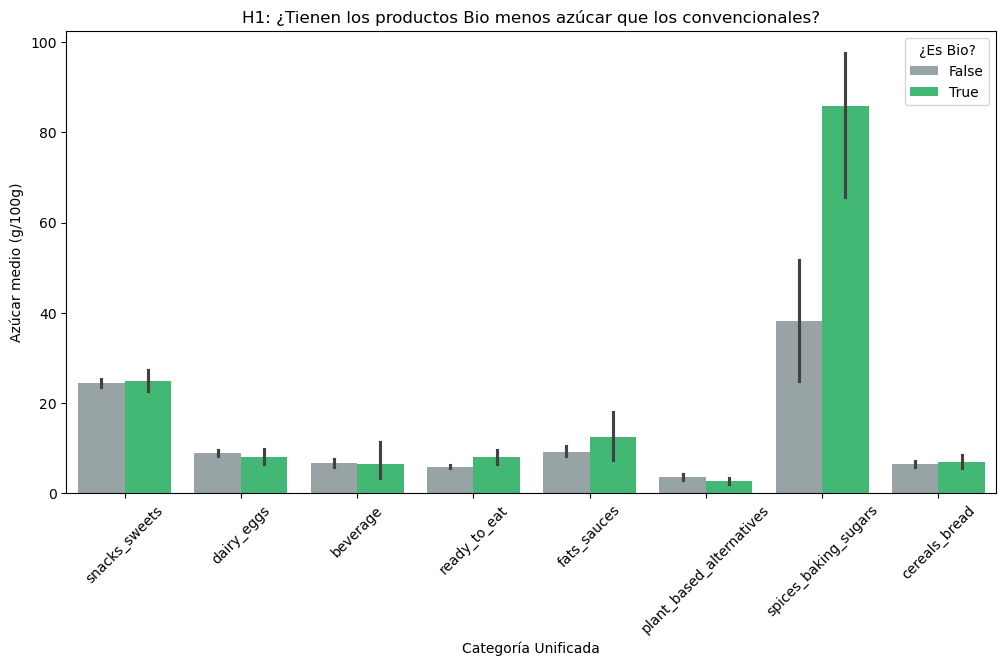

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el gráfico
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_analisis, 
    x='category_unified', 
    y='sugars_100g', 
    hue='is_bio',
    palette={True: '#2ecc71', False: '#95a5a6'} # Verde para Bio, Gris para Convencional
)

plt.xticks(rotation=45)
plt.title('H1: ¿Tienen los productos Bio menos azúcar que los convencionales?')
plt.ylabel('Azúcar medio (g/100g)')
plt.xlabel('Categoría Unificada')
plt.legend(title='¿Es Bio?')
plt.show()

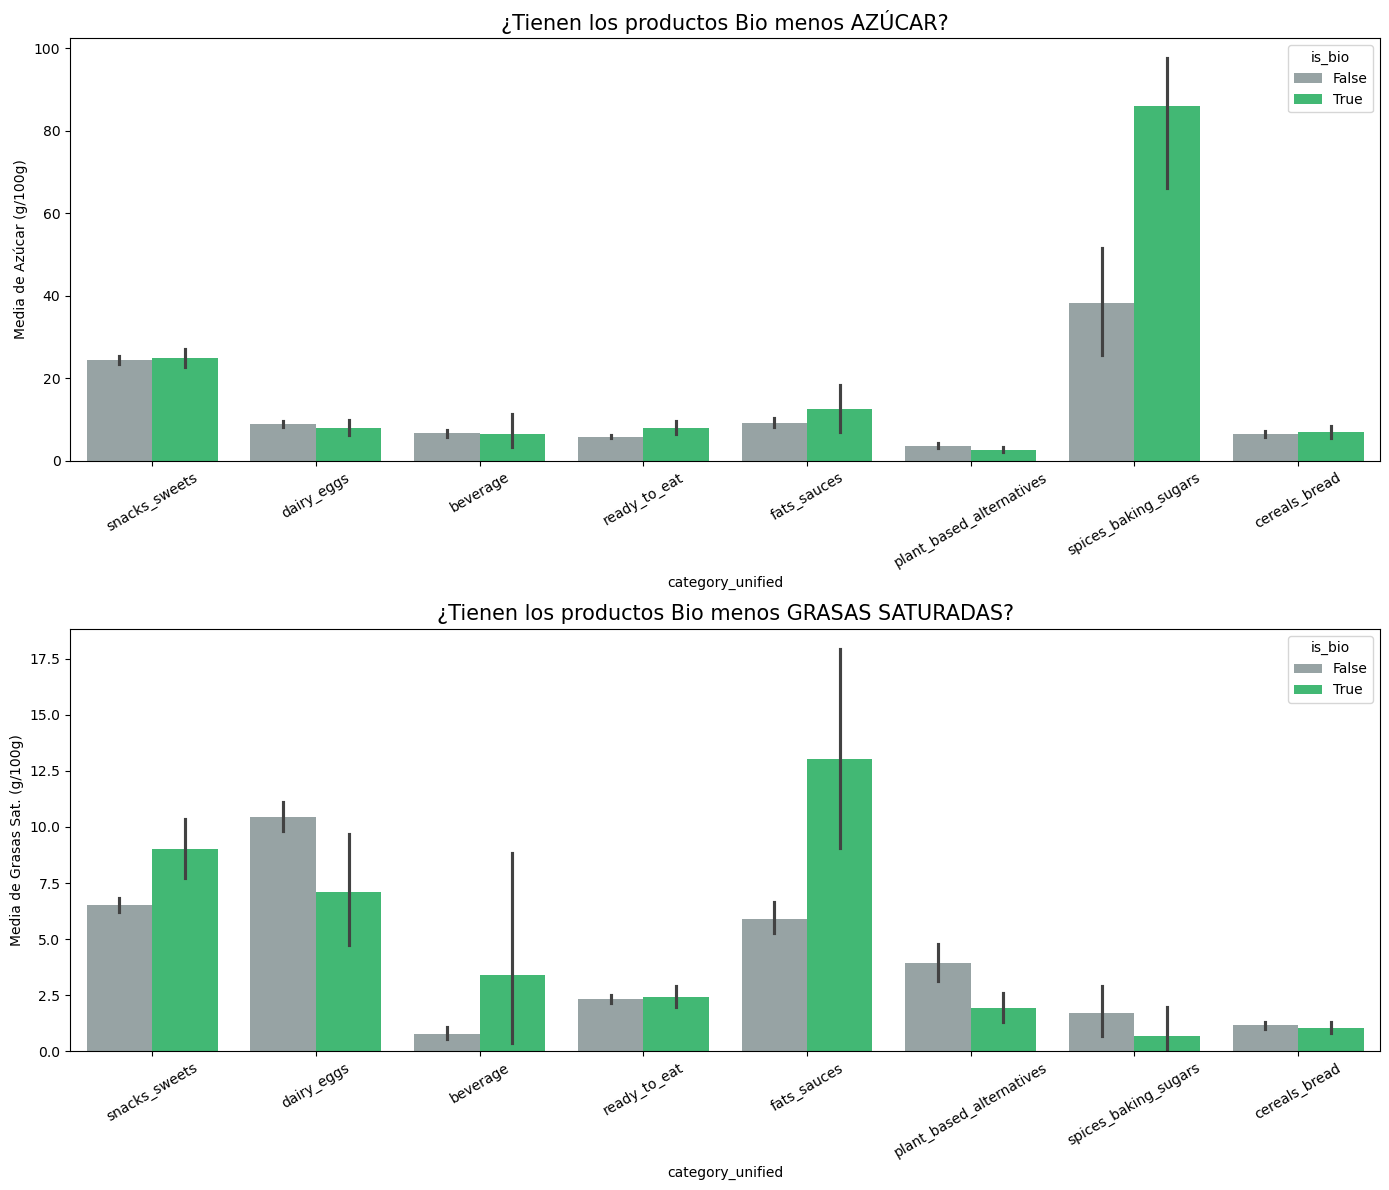

--- RESUMEN DE MEDIAS POR CATEGORÍA ---
                                 sugars_100g  saturated-fat_100g
category_unified         is_bio                                 
beverage                 False      6.606586            0.782340
                         True       6.488571            3.389722
cereals_bread            False      6.468871            1.146578
                         True       6.922607            1.054155
dairy_eggs               False      8.895186           10.456243
                         True       8.002254            7.120207
fats_sauces              False      9.206460            5.914222
                         True      12.425325           13.051948
plant_based_alternatives False      3.583394            3.928606
                         True       2.631837            1.912832
ready_to_eat             False      5.824018            2.343326
                         True       7.923941            2.412868
snacks_sweets            False     24.426807      

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Aseguramos que tenemos la marca Bio/Organic
# Usamos tu DataFrame 'food_countries' que ya tiene la categoría unificada
food_countries['is_bio'] = food_countries['labels'].str.contains('Bio|Organic|Ecológico', case=False, na=False)

# 2. Seleccionamos las categorías que tienen suficiente representación de ambos grupos
# (Al menos 10 productos de cada tipo para que la media sea fiable)
counts = food_countries.groupby(['category_unified', 'is_bio']).size().unstack(fill_value=0)
categorias_validas = counts[(counts[True] >= 10) & (counts[False] >= 10)].index
df_plot = food_countries[food_countries['category_unified'].isin(categorias_validas)]

# 3. Visualización: Comparativa de Azúcar y Grasas Saturadas
fig, ax = plt.subplots(2, 1, figsize=(14, 12))

# Gráfico de Azúcar
sns.barplot(
    data=df_plot, 
    x='category_unified', 
    y='sugars_100g', 
    hue='is_bio', 
    ax=ax[0],
    palette={True: '#2ecc71', False: '#95a5a6'}
)
ax[0].set_title('¿Tienen los productos Bio menos AZÚCAR?', fontsize=15)
ax[0].set_ylabel('Media de Azúcar (g/100g)')
ax[0].tick_params(axis='x', rotation=30)

# Gráfico de Grasas Saturadas
sns.barplot(
    data=df_plot, 
    x='category_unified', 
    y='saturated-fat_100g', 
    hue='is_bio', 
    ax=ax[1],
    palette={True: '#2ecc71', False: '#95a5a6'}
)
ax[1].set_title('¿Tienen los productos Bio menos GRASAS SATURADAS?', fontsize=15)
ax[1].set_ylabel('Media de Grasas Sat. (g/100g)')
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# 4. Reporte numérico rápido
print("--- RESUMEN DE MEDIAS POR CATEGORÍA ---")
print(df_plot.groupby(['category_unified', 'is_bio'])[['sugars_100g', 'saturated-fat_100g']].mean())

is_bio                       False      True      diff
category_unified                                      
beverage                  3.312914  3.205882 -0.107032
cereals_bread             3.695378  3.951807  0.256429
dairy_eggs                2.713672  2.950820  0.237148
fats_sauces               2.383657  2.676471  0.292814
plant_based_alternatives  3.131507  3.654135  0.522628
ready_to_eat              3.506936  3.726804  0.219868
snacks_sweets             2.090382  2.259786  0.169405
spices_baking_sugars      1.800000  1.000000 -0.800000


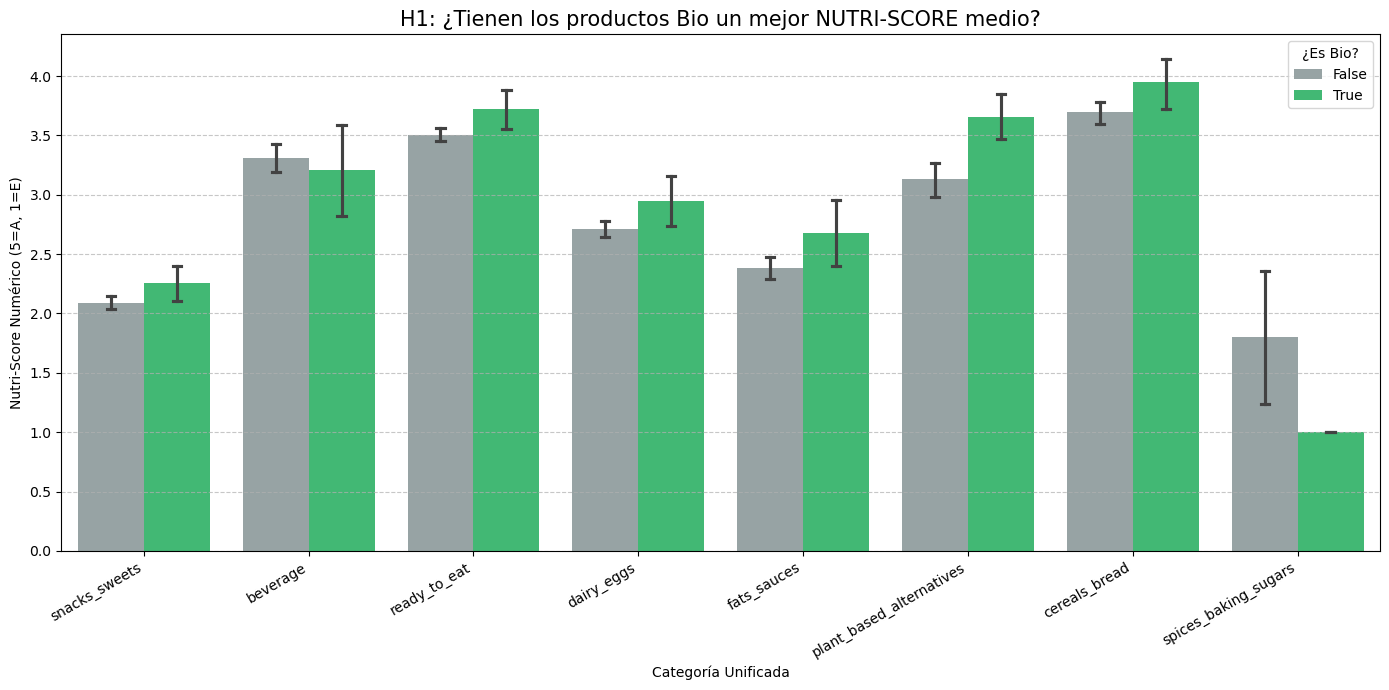

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Map Nutri-Score to numerical values (a=5, b=4, c=3, d=2, e=1)
nutri_map = {'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1}
food_countries['nutriscore_num'] = food_countries['nutriscore_grade'].map(nutri_map)

# 2. Filter categories with enough representation (Bio vs Non-Bio)
# We already have 'is_bio' and 'category_unified' from previous steps.
# Using the same logic: at least 10 products of each type.
counts = food_countries.dropna(subset=['nutriscore_num']).groupby(['category_unified', 'is_bio']).size().unstack(fill_value=0)
categorias_validas = counts[(counts[True] >= 10) & (counts[False] >= 10)].index
df_nutri = food_countries[food_countries['category_unified'].isin(categorias_validas)].dropna(subset=['nutriscore_num'])

# 3. Visualization
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_nutri,
    x='category_unified',
    y='nutriscore_num',
    hue='is_bio',
    palette={True: '#2ecc71', False: '#95a5a6'},
    capsize=.1
)

plt.xticks(rotation=30, ha='right')
plt.title('H1: ¿Tienen los productos Bio un mejor NUTRI-SCORE medio?', fontsize=15)
plt.ylabel('Nutri-Score Numérico (5=A, 1=E)')
plt.xlabel('Categoría Unificada')
plt.legend(title='¿Es Bio?', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('nutriscore_bio_comparison.png')

# 4. Statistical Summary
summary = df_nutri.groupby(['category_unified', 'is_bio'])['nutriscore_num'].mean().unstack()
summary['diff'] = summary[True] - summary[False]
print(summary)

--- MEDIAS GRADO NOVA ---
is_bio                       False     True 
category_unified                            
beverage                  2.581395  2.051282
cereals_bread             3.208155  2.890244
dairy_eggs                3.133582  2.672131
fats_sauces               3.359102  2.473684
plant_based_alternatives  3.632979  3.262774
ready_to_eat              3.389563  3.035897
snacks_sweets             3.646319  3.206897
spices_baking_sugars      2.962963  1.900000

--- MEDIAS ECO-SCORE ---
is_bio                       False     True 
category_unified                            
beverage                  3.006410  3.485714
cereals_bread             3.878866  4.567568
dairy_eggs                2.873027  4.294643
fats_sauces               3.494413  3.959459
plant_based_alternatives  4.038585  4.899225
ready_to_eat              3.608795  4.424051
snacks_sweets             3.101067  3.886926
spices_baking_sugars      3.500000  4.600000


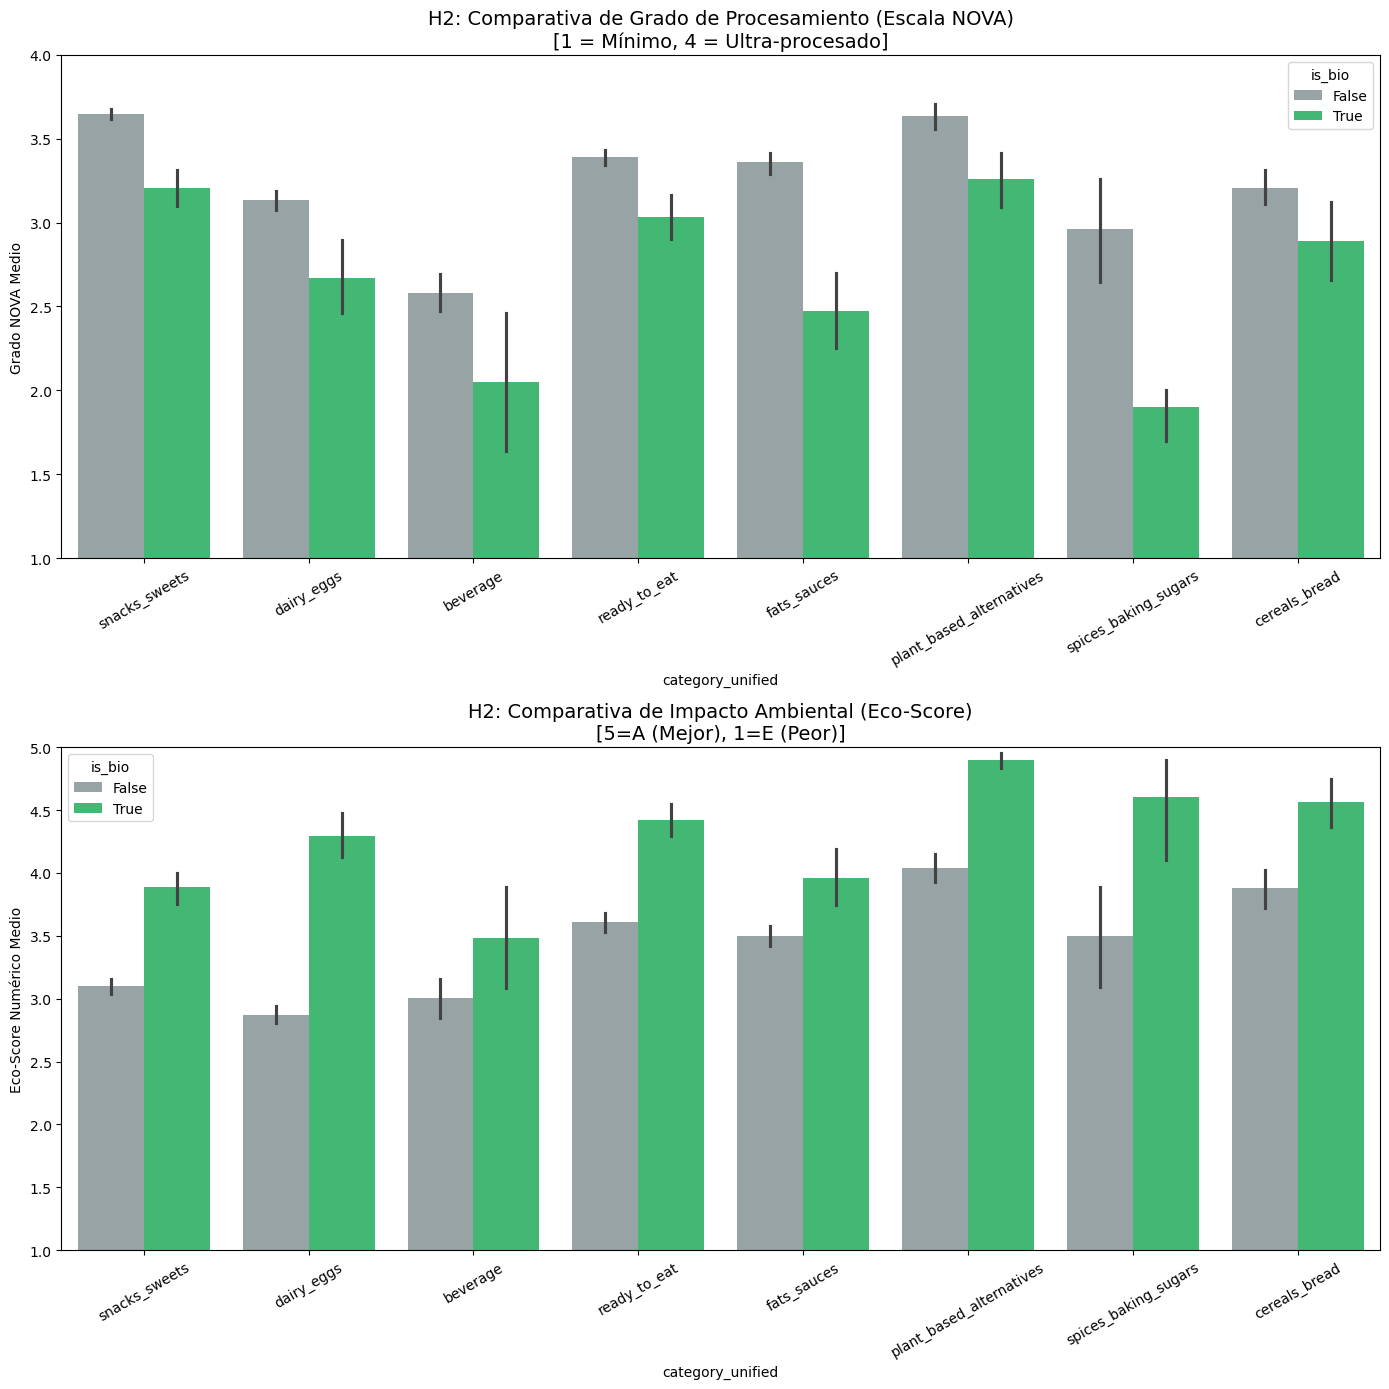

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Using the existing 'df' which already has 'category_unified' and 'is_bio'
# 1. Prepare Eco-Score (a=5, b=4, c=3, d=2, e=1)
eco_map = {'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1, 'a-plus': 5} # a-plus exists in some OFF versions
foods['ecoscore_num'] = foods['ecoscore_grade'].str.lower().map(eco_map)

# 2. Filter valid categories for NOVA (representation > 10 in both groups)
counts_nova = foods.dropna(subset=['nova_group']).groupby(['category_unified', 'is_bio']).size().unstack(fill_value=0)
valid_cats_nova = counts_nova[(counts_nova[True] >= 10) & (counts_nova[False] >= 10)].index
df_nova = foods[foods['category_unified'].isin(valid_cats_nova)].copy()

# 3. Filter valid categories for Eco-Score
counts_eco = foods.dropna(subset=['ecoscore_num']).groupby(['category_unified', 'is_bio']).size().unstack(fill_value=0)
valid_cats_eco = counts_eco[(counts_eco[True] >= 10) & (counts_eco[False] >= 10)].index
df_eco = foods[foods['category_unified'].isin(valid_cats_eco)].copy()

# 4. Plots
fig, ax = plt.subplots(2, 1, figsize=(14, 14))

# Plot NOVA Group (1 is low processing, 4 is ultra-processed)
sns.barplot(
    data=df_nova,
    x='category_unified',
    y='nova_group',
    hue='is_bio',
    palette={True: '#2ecc71', False: '#95a5a6'},
    ax=ax[0]
)
ax[0].set_title('H2: Comparativa de Grado de Procesamiento (Escala NOVA)\n[1 = Mínimo, 4 = Ultra-procesado]', fontsize=14)
ax[0].set_ylabel('Grado NOVA Medio')
ax[0].set_ylim(1, 4)
ax[0].tick_params(axis='x', rotation=30)

# Plot Eco-Score (5 is A/Best, 1 is E/Worst)
sns.barplot(
    data=df_eco,
    x='category_unified',
    y='ecoscore_num',
    hue='is_bio',
    palette={True: '#2ecc71', False: '#95a5a6'},
    ax=ax[1]
)
ax[1].set_title('H2: Comparativa de Impacto Ambiental (Eco-Score)\n[5=A (Mejor), 1=E (Peor)]', fontsize=14)
ax[1].set_ylabel('Eco-Score Numérico Medio')
ax[1].set_ylim(1, 5)
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('nova_eco_comparison.png')

# Summary Stats
stats_nova = df_nova.groupby(['category_unified', 'is_bio'])['nova_group'].mean().unstack()
stats_eco = df_eco.groupby(['category_unified', 'is_bio'])['ecoscore_num'].mean().unstack()

print("--- MEDIAS GRADO NOVA ---")
print(stats_nova)
print("\n--- MEDIAS ECO-SCORE ---")
print(stats_eco)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtramos solo por la categoría de conveniencia
ready_to_eat = food_countries[food_countries['category_unified'] == 'ready_to_eat'].copy()

# 2. Definimos listas de marcas para clasificar
marcas_blancas = ['hacendado', 'carrefour', 'lidl', 'aldi', 'tesco', 'sainsbury', 'auchan', 'alcampo', 'mercadona', 'eridane', 'milbona']
multinacionales = ['nestle', 'unilever', 'heinz', 'danone', 'mondelez', 'pepsico', 'mars', 'maggi', 'knorr', 'dr. oetker', 'buitoni']

def clasificar_marca(brand):
    if pd.isna(brand): return 'Otros'
    brand = str(brand).lower()
    if any(m in brand for m in marcas_blancas):
        return 'Marca Blanca'
    if any(m in brand for m in multinacionales):
        return 'Multinacional'
    return 'Otros'

ready_to_eat['tipo_marca'] = ready_to_eat['brands'].apply(clasificar_marca)

# 3. Filtramos "Otros" para comparar solo los dos grupos de interés
df_h3 = ready_to_eat[ready_to_eat['tipo_marca'] != 'Otros']

print(f"Productos analizados: {df_h3['tipo_marca'].value_counts()}")

Productos analizados: tipo_marca
Marca Blanca     330
Multinacional    104
Name: count, dtype: int64


/tmp/ipykernel_6698/3651075228.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_h3['nutriscore_num'] = df_h3['nutriscore_grade'].str.lower().map(nutri_map)
/tmp/ipykernel_6698/3651075228.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_h3, x='tipo_marca', y='nutriscore_num', ax=ax[0], palette='Set2')
/tmp/ipykernel_6698/3651075228.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_h3, x='tipo_marca', y='sugars_100g', ax=ax[

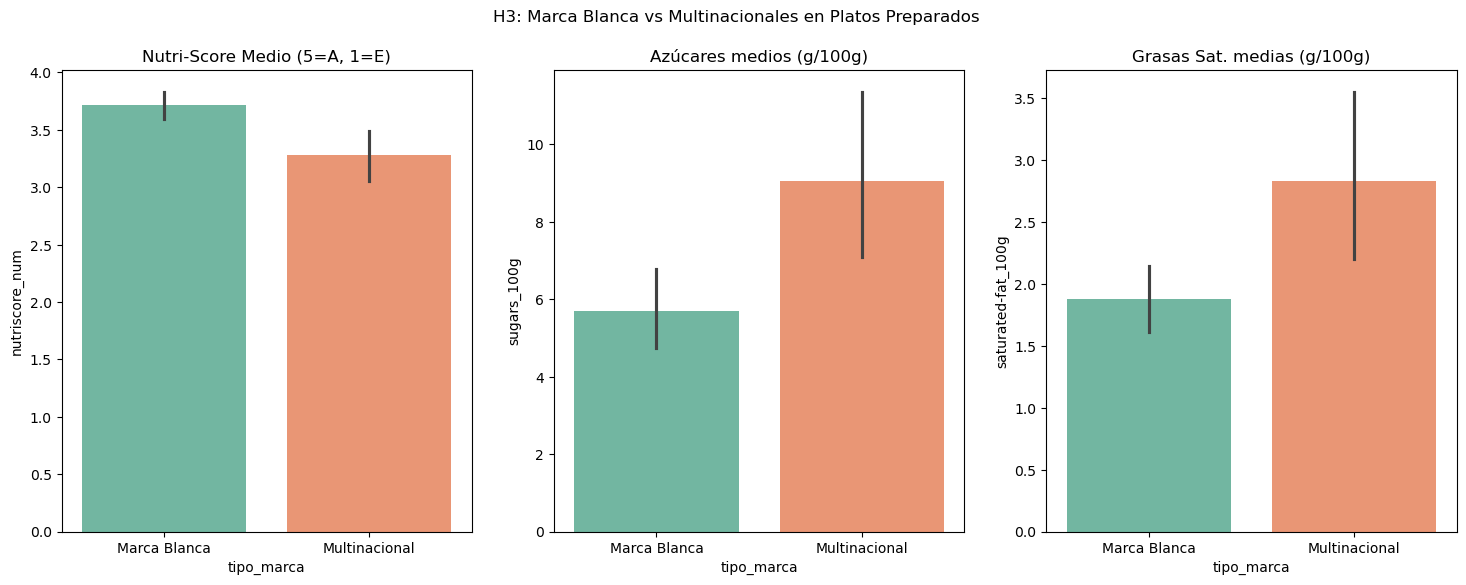

               nutriscore_num  sugars_100g  saturated-fat_100g  salt_100g
tipo_marca                                                               
Marca Blanca         3.712934     5.698409            1.873737   0.631205
Multinacional        3.281250     9.057282            2.828719  11.263456


In [ ]:
# Mapeamos Nutri-Score a numérico para la gráfica
nutri_map = {'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1}
df_h3['nutriscore_num'] = df_h3['nutriscore_grade'].str.lower().map(nutri_map)

# Gráfico de comparación
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=df_h3, x='tipo_marca', y='nutriscore_num', ax=ax[0], palette='Set2')
ax[0].set_title('Nutri-Score Medio (5=A, 1=E)')

sns.barplot(data=df_h3, x='tipo_marca', y='sugars_100g', ax=ax[1], palette='Set2')
ax[1].set_title('Azúcares medios (g/100g)')

sns.barplot(data=df_h3, x='tipo_marca', y='saturated-fat_100g', ax=ax[2], palette='Set2')
ax[2].set_title('Grasas Sat. medias (g/100g)')

plt.suptitle('H3: Marca Blanca vs Multinacionales en Platos Preparados')
plt.show()

# Estadísticas descriptivas
print(df_h3.groupby('tipo_marca')[['nutriscore_num', 'sugars_100g', 'saturated-fat_100g', 'salt_100g']].mean())